In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
transactions = pd.read_csv(r'C:\Users\mahmoud\Downloads\final_transactions.csv')
articles = pd.read_csv(r'C:\Users\mahmoud\Downloads\final_articles.csv')
customers = pd.read_csv(r'C:\Users\mahmoud\Downloads\final_customers.csv')

print("Transactions:", transactions.shape)
print("Articles:", articles.shape)
print("Customers:", customers.shape)

Transactions: (50000, 5)
Articles: (50000, 25)
Customers: (50000, 7)


In [9]:
# Merge Data
merged = transactions.merge(articles[['article_id','prod_name','product_type_name','department_name','garment_group_name','colour_group_name','index_group_name']], on='article_id', how='left')
merged = merged.merge(customers[['customer_id','age','club_member_status','fashion_news_frequency']], on='customer_id', how='left')
merged['revenue_SEK'] = merged['price'] * 590
merged['sales_channel'] = merged['sales_channel_id'].map({1: 'In-Store', 2: 'Online'})

print(merged.shape)
merged.head()

(50000, 16)


,t_dat,customer_id,article_id,price,sales_channel_id,prod_name,product_type_name,department_name,garment_group_name,colour_group_name,index_group_name,age,club_member_status,fashion_news_frequency,revenue_SEK,sales_channel
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,Atlanta Push Body Harlow,Underwear body,Expressive Lingerie,"Under-, Nightwear",Black,Ladieswear,NaN,NaN,NaN,29.99,Online
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,Rae Push (Melbourne) 2p,Bra,Casual Lingerie,"Under-, Nightwear",Light Pink,Ladieswear,NaN,NaN,NaN,17.99,Online
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,Inca Jumper,Sweater,Tops Knitwear DS,Knitwear,Pink,Divided,32.0,ACTIVE,Regularly,8.99,Online
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,W YODA KNIT OL OFFER,Sweater,Campaigns,Special Offers,Pink,Ladieswear,32.0,ACTIVE,Regularly,9.99,Online
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,W YODA KNIT OL OFFER,Sweater,Campaigns,Special Offers,Dark Green,Ladieswear,32.0,ACTIVE,Regularly,9.99,Online


In [10]:
# Revenue Analysis by Department
dept_revenue = merged.groupby('department_name')['revenue_SEK'].sum().sort_values(ascending=False).head(10)
print("Top 10 Departments by Revenue:")
print(dept_revenue)

# Revenue by Category
cat_revenue = merged.groupby('index_group_name')['revenue_SEK'].sum().sort_values(ascending=False)
print("\nRevenue by Category:")
print(cat_revenue)

# Revenue by Sales Channel
channel_revenue = merged.groupby('sales_channel')['revenue_SEK'].sum()
print("\nRevenue by Sales Channel:")
print(channel_revenue)

Top 10 Departments by Revenue:
department_name
Knitwear               71761.71
Trouser                66907.50
Outwear                46014.89
Blouse                 41388.37
Denim Trousers         40414.26
Jersey                 25313.11
Campaigns              23955.47
Expressive Lingerie    23278.05
Trousers               21490.89
Jersey Basic           20037.10
Name: revenue_SEK, dtype: float64

Revenue by Category:
index_group_name
Ladieswear       528298.28
Divided          187465.06
Baby/Children     51188.50
Menswear          37041.93
Sport             27950.88
Name: revenue_SEK, dtype: float64

Revenue by Sales Channel:
sales_channel
In-Store    230235.06
Online      633059.83
Name: revenue_SEK, dtype: float64


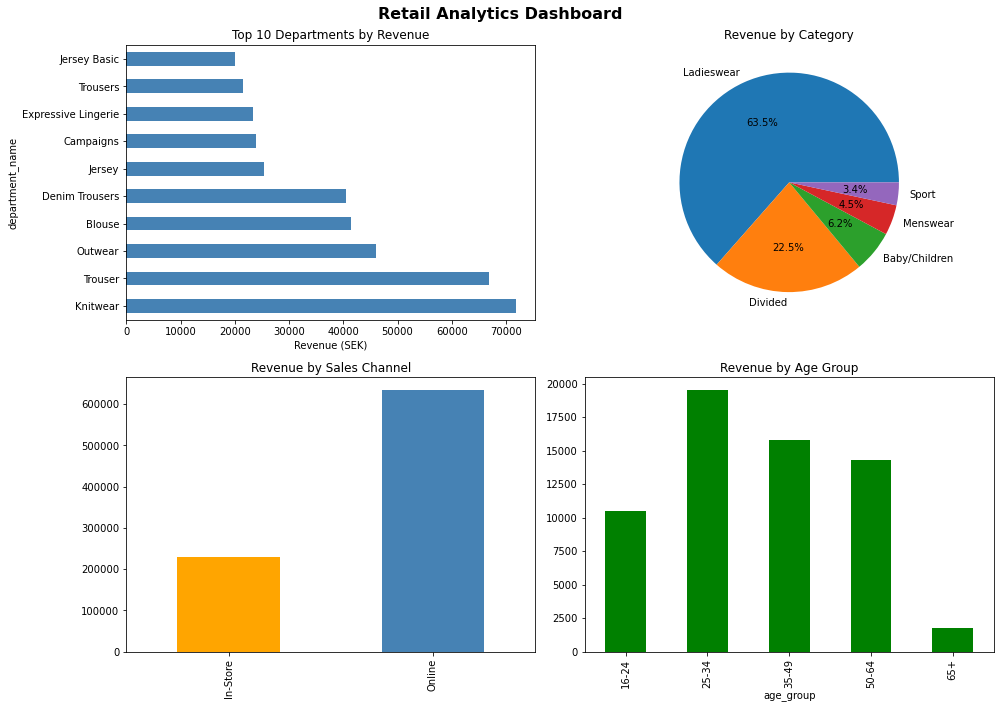

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Retail Analytics Dashboard', fontsize=16, fontweight='bold')

# 1. Top Departments
dept_revenue.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 10 Departments by Revenue')
axes[0,0].set_xlabel('Revenue (SEK)')

# 2. Category Pie
cat_revenue.plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title('Revenue by Category')
axes[0,1].set_ylabel('')

# 3. Sales Channel
channel_revenue.plot(kind='bar', ax=axes[1,0], color=['orange','steelblue'])
axes[1,0].set_title('Revenue by Sales Channel')
axes[1,0].set_xlabel('')

# 4. Age Group
merged['age_group'] = pd.cut(merged['age'], bins=[0,24,34,49,64,100], labels=['16-24','25-34','35-49','50-64','65+'])
merged.groupby('age_group', observed=True)['revenue_SEK'].sum().plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Revenue by Age Group')

plt.tight_layout()
plt.show()

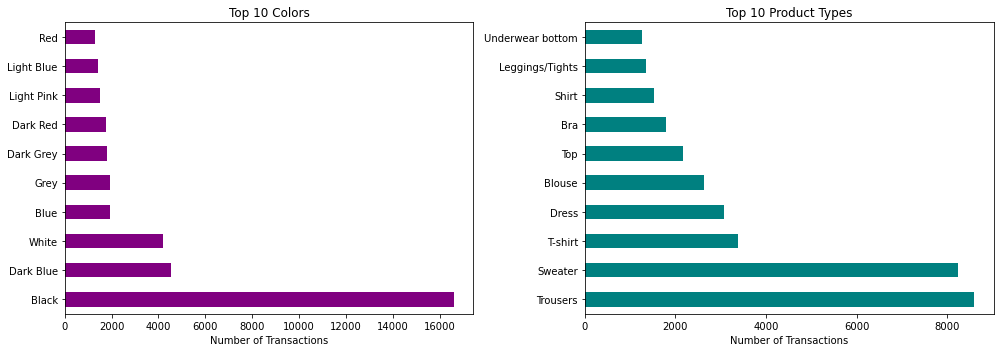

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top Colors
merged['colour_group_name'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='purple')
axes[0].set_title('Top 10 Colors')
axes[0].set_xlabel('Number of Transactions')

# Top Product Types
merged['product_type_name'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 10 Product Types')
axes[1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()

In [13]:
# Customer Analysis
print("=== Customer Analysis ===")
print("\nAge Statistics:")
print(merged['age'].describe())

print("\nClub Member Status:")
print(customers['club_member_status'].value_counts())

print("\nFashion News Frequency:")
print(customers['fashion_news_frequency'].value_counts())

# Top Customers by Revenue
top_customers = merged.groupby('customer_id')['revenue_SEK'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Customers by Revenue:")
print(top_customers)

=== Customer Analysis ===

Age Statistics:
count    3549.000000
mean       38.065652
std        13.425015
min        18.000000
25%        26.000000
50%        35.000000
75%        49.000000
max        78.000000
Name: age, dtype: float64

Club Member Status:
ACTIVE        49371
PRE-CREATE      629
Name: club_member_status, dtype: int64

Fashion News Frequency:
Regularly    49877
Monthly         80
NONE            43
Name: fashion_news_frequency, dtype: int64

Top 10 Customers by Revenue:
customer_id
4cccf0bb281678f22d83dfbdb0e350c3b6640d68bc33d9a28a43c2ff2fd7c7be    1040.33
68df3fb4059bc5b85549bf6424c6076888e80f762178e485820089648c2a08a1     599.82
6ac05cd6b187d3b2c532351d79d641f9dd9827fe58069353f5e3bd494e7892c9     597.66
fc17f04209372eb9feace41de48530e032486491880b6a14f03a92de4ee6ae8b     585.76
f214f50b272ac37bb4c6c723090042a553e143a23f891bdb38c1a886604170fe     556.81
a4bbda8479e849a322c37ac169c55ee1d0a191f2c931bab1c6c891d111b818ba     545.42
3e34dc15e897e2cb7571e14420f101118ba339a0

In [14]:
# Summary Statistics
print("=== Final Summary ===")
print(f"Total Revenue: {merged['revenue_SEK'].sum():,.2f} SEK")
print(f"Total Transactions: {len(merged):,}")
print(f"Unique Customers: {merged['customer_id'].nunique():,}")
print(f"Unique Products: {merged['article_id'].nunique():,}")
print(f"Best Selling Department: {merged.groupby('department_name')['revenue_SEK'].sum().idxmax()}")
print(f"Best Selling Category: {merged.groupby('index_group_name')['revenue_SEK'].sum().idxmax()}")
print(f"Most Popular Color: {merged['colour_group_name'].value_counts().index[0]}")
print(f"Most Popular Product: {merged['product_type_name'].value_counts().index[0]}")
print(f"Online vs InStore: {merged['sales_channel'].value_counts().to_dict()}")

=== Final Summary ===
Total Revenue: 863,294.89 SEK
Total Transactions: 50,000
Unique Customers: 15,891
Unique Products: 12,334
Best Selling Department: Knitwear
Best Selling Category: Ladieswear
Most Popular Color: Black
Most Popular Product: Trousers
Online vs InStore: {'Online': 35800, 'In-Store': 14200}
